In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

In [2]:
# Load dataset
df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


[[90 10]
 [27 27]]
              precision    recall  f1-score   support

           0       0.77      0.90      0.83       100
           1       0.73      0.50      0.59        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.71       154
weighted avg       0.76      0.76      0.75       154



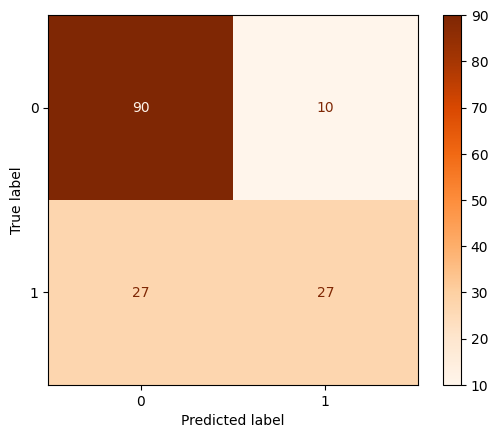

In [12]:
# Split features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X,  y, test_size=0.2, random_state=101, stratify=y)

# Scaling
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix display
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,cmap='Oranges')